# Heart Disease Prediction Using Random Forest

## 1. Setup & Data Loading

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, RocCurveDisplay,
    recall_score, precision_score, f1_score, accuracy_score
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset
df = pd.read_csv('heart_disease_uci.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 2. Exploratory Data Analysis

### Missing Values

          Missing Count  Missing %
ca                  611       66.4
thal                486       52.8
slope               309       33.6
fbs                  90        9.8
oldpeak              62        6.7
trestbps             59        6.4
thalch               55        6.0
exang                55        6.0
chol                 30        3.3
restecg               2        0.2


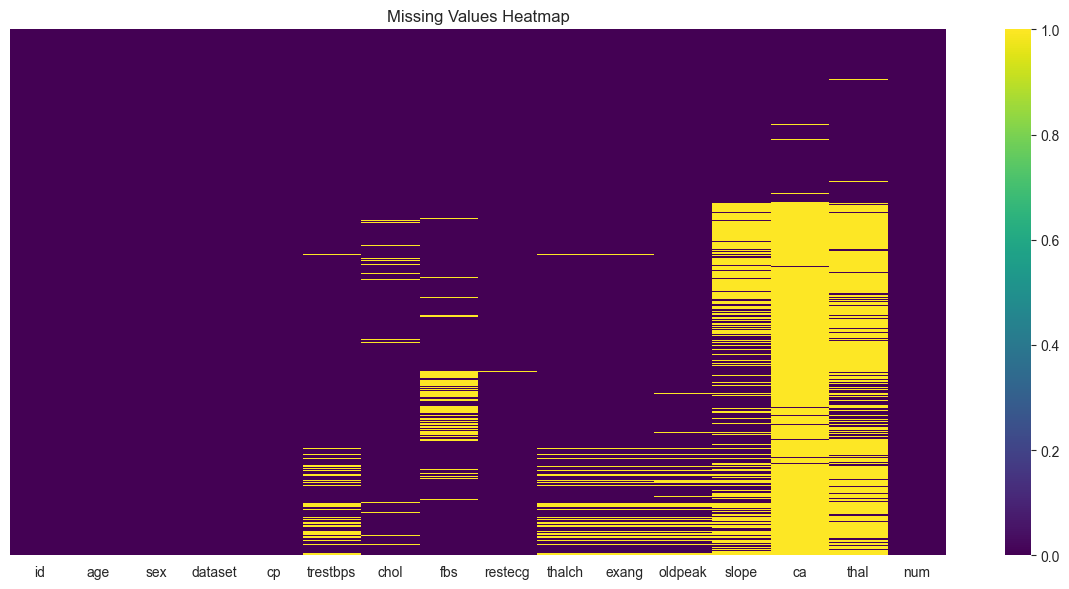

In [5]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))

# Missing values heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### Target Variable Distribution

Original target `num` ranges 0-4. Binarized to: **0 = no disease**, **1 = disease present**.

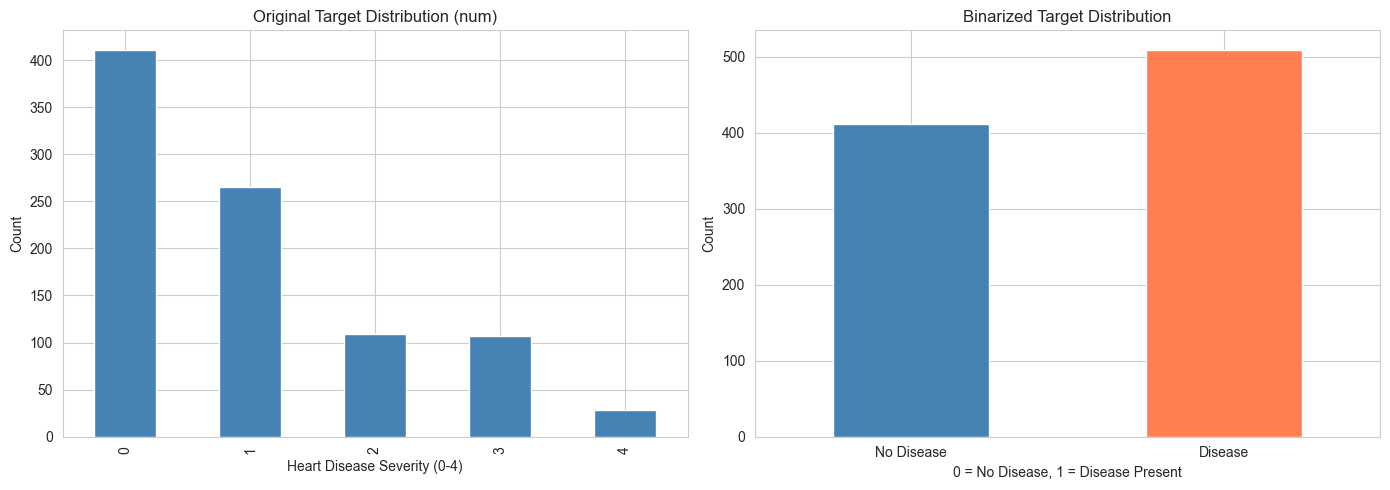

Class balance: {1: 0.553, 0: 0.447}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original target distribution
df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Original Target Distribution (num)')
axes[0].set_xlabel('Heart Disease Severity (0-4)')
axes[0].set_ylabel('Count')

# Binarized target distribution
target_binary = (df['num'] > 0).astype(int)
target_binary.value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Binarized Target Distribution')
axes[1].set_xlabel('0 = No Disease, 1 = Disease Present')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Disease', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

print(f"Class balance: {target_binary.value_counts(normalize=True).round(3).to_dict()}")

### Feature Distributions by Target

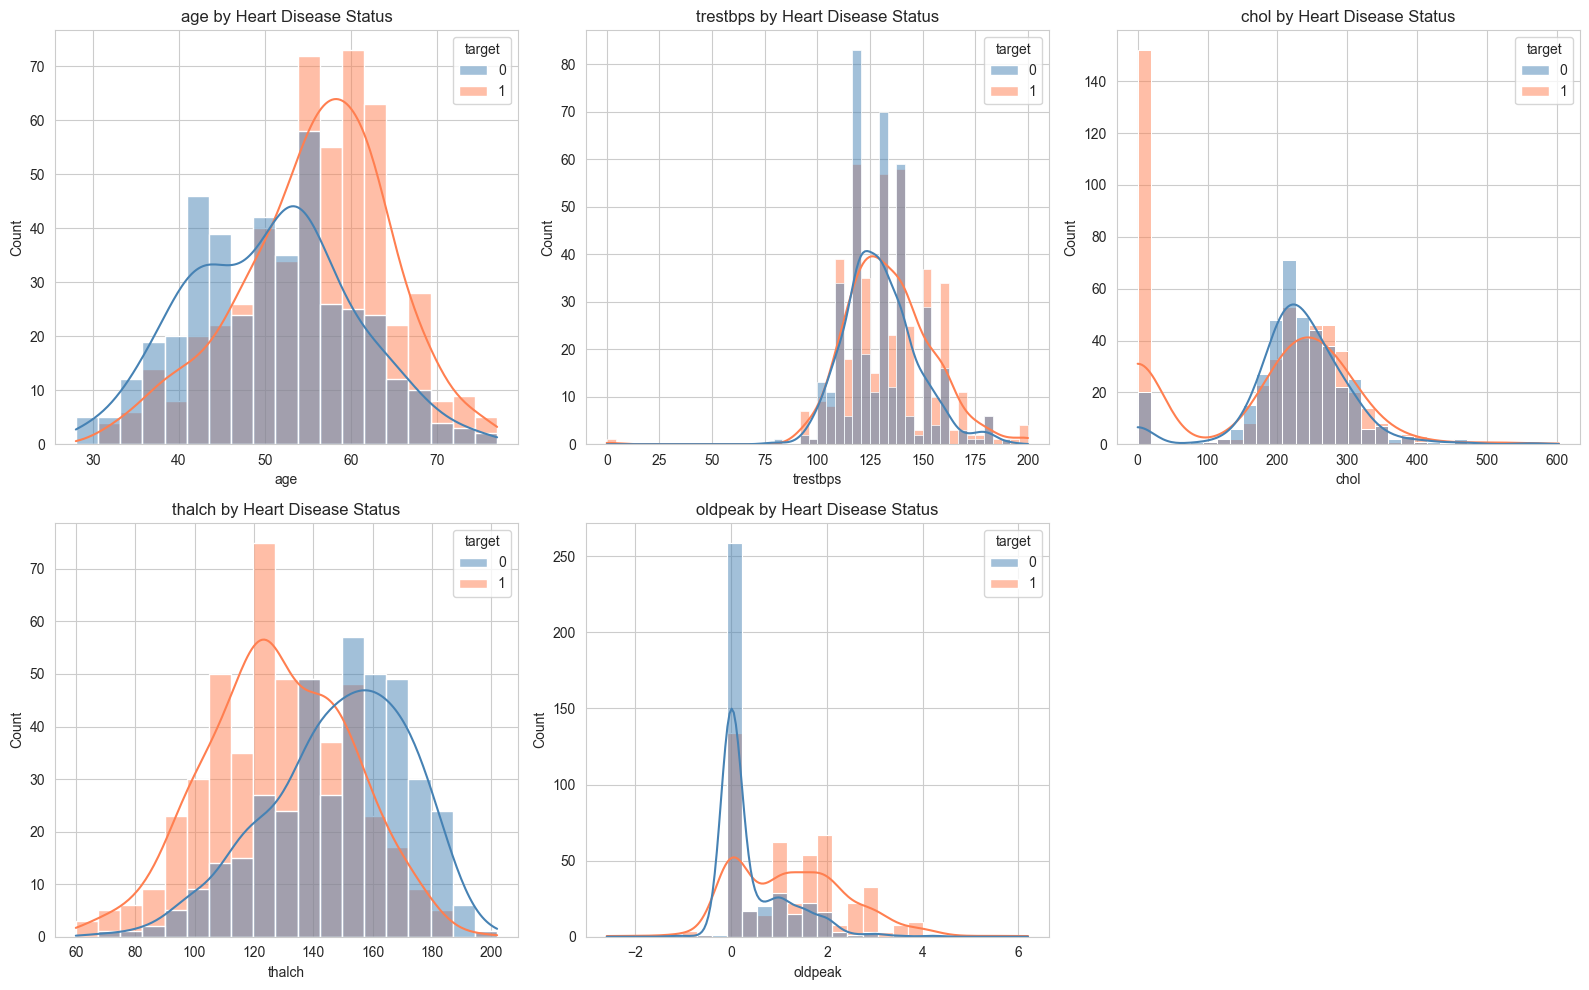

In [7]:
# Add binarized target for visualization
df['target'] = (df['num'] > 0).astype(int)

# Numerical feature distributions
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i], palette=['steelblue', 'coral'])
    axes[i].set_title(f'{col} by Heart Disease Status')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

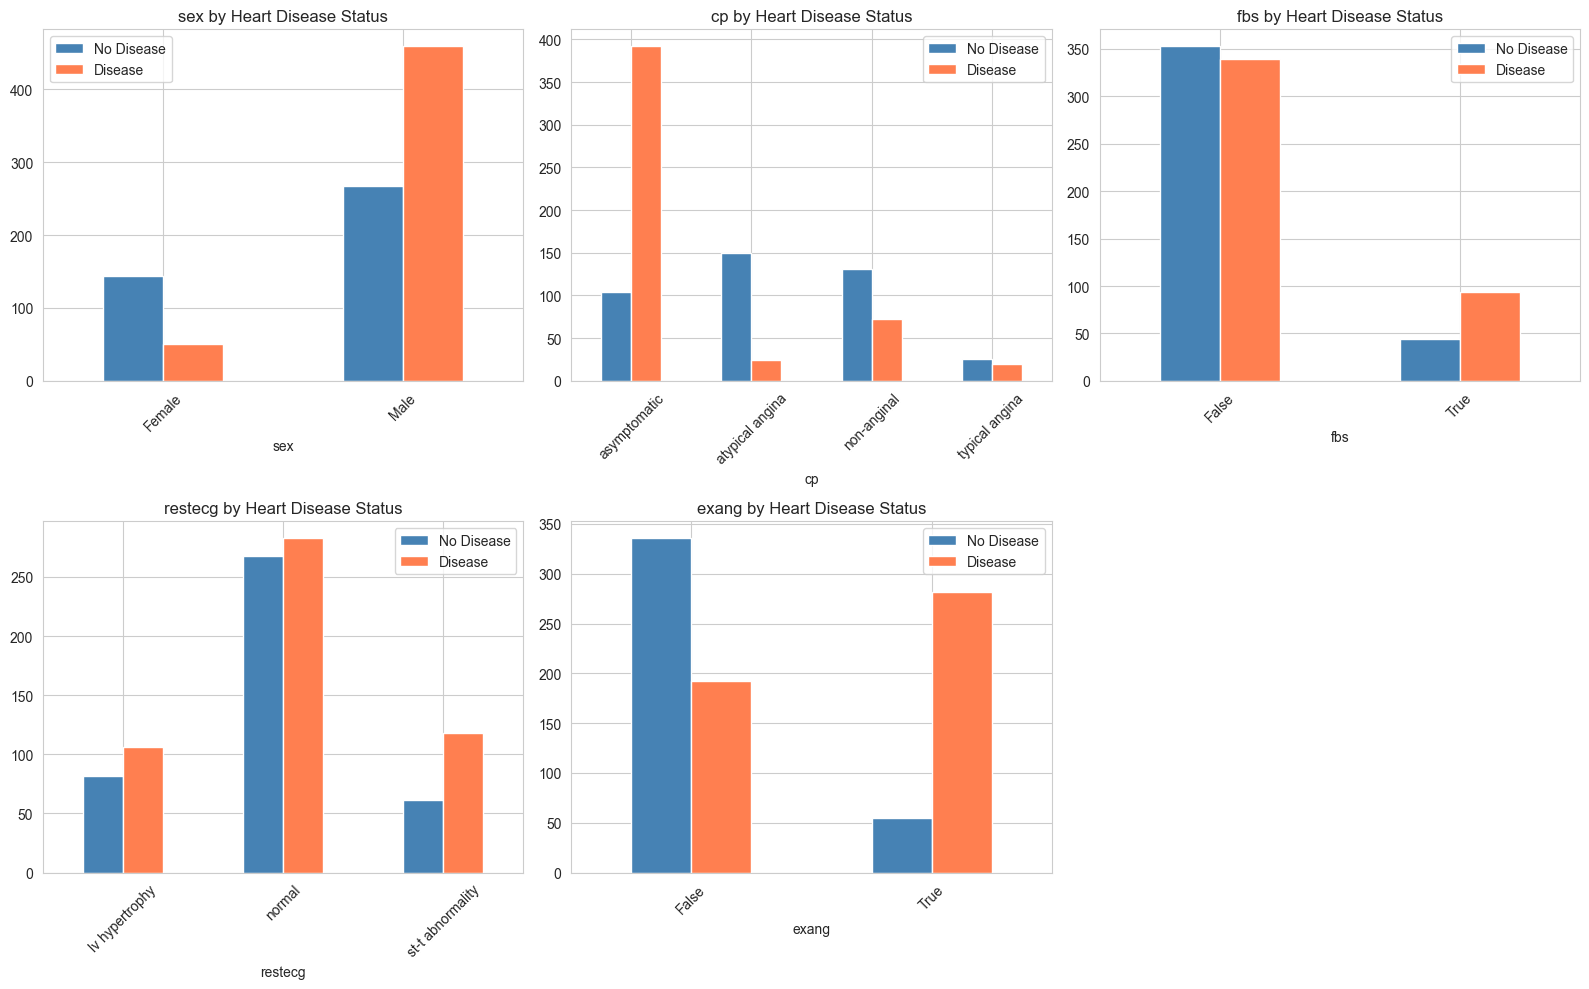

In [8]:
# Categorical feature distributions
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'])
    axes[i].set_title(f'{col} by Heart Disease Status')
    axes[i].set_xlabel(col)
    axes[i].legend(['No Disease', 'Disease'])
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Correlation Matrix (Numerical Features)

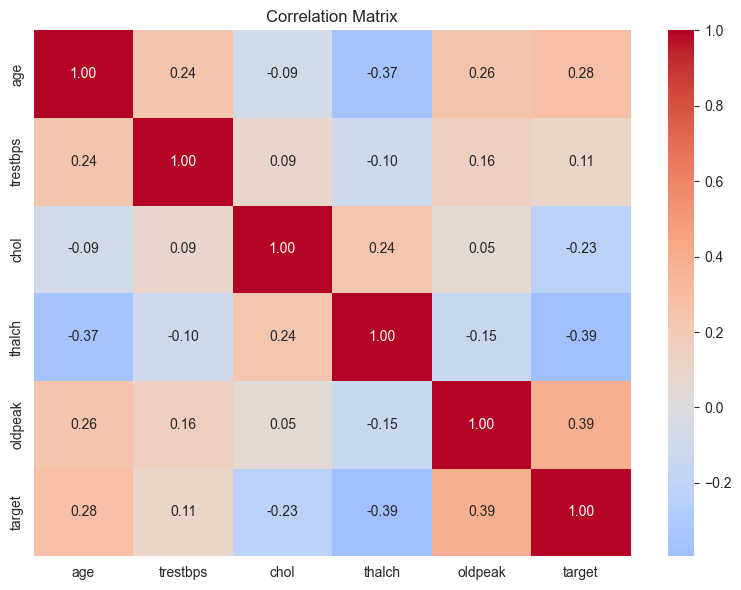

In [9]:
corr_cols = numerical_features + ['target']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Dropped columns:
- `id`, `dataset`: not predictive
- `ca` (66% missing), `thal` (53% missing): too much missing data to impute reliably
- `num`: replaced by binarized `target`

Kept `slope` (34% missing) and imputed with most frequent value.

In [10]:
# Drop non-predictive and high-missingness columns
df_model = df.drop(columns=['id', 'dataset', 'ca', 'thal', 'num'])

print(f"Modeling dataset shape: {df_model.shape}")
print(f"\nRemaining columns: {list(df_model.columns)}")
print(f"\nRemaining missing values:\n{df_model.isnull().sum()[df_model.isnull().sum() > 0]}")

Modeling dataset shape: (920, 12)

Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'target']

Remaining missing values:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
dtype: int64


### Preprocessing Pipeline

- **Numerical** (`age`, `trestbps`, `chol`, `thalch`, `oldpeak`): median imputation, then StandardScaler
- **Categorical** (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`): most-frequent imputation, then one-hot encoding

Preprocessor is inside the sklearn Pipeline to prevent data leakage during cross-validation.

In [11]:
# Define feature groups
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']

# Numerical pipeline: impute with median, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute with most frequent, then one-hot encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


### Train/Test Split (80/20, stratified)

In [12]:
# Split features and target
X = df_model.drop(columns=['target'])
y = df_model['target']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 736 samples
Test set:     184 samples

Training class distribution:
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Test class distribution:
target
1    0.554
0    0.446
Name: proportion, dtype: float64


## 4. Model Training & Cross-Validation

In [13]:
# Build the full pipeline: preprocessor + Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']

cv_scores = cross_validate(
    rf_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True
)

# Display results
cv_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1 Score', 'ROC-AUC'],
    'Train (mean +/- std)': [
        f"{cv_scores['train_accuracy'].mean():.3f} +/- {cv_scores['train_accuracy'].std():.3f}",
        f"{cv_scores['train_recall'].mean():.3f} +/- {cv_scores['train_recall'].std():.3f}",
        f"{cv_scores['train_precision'].mean():.3f} +/- {cv_scores['train_precision'].std():.3f}",
        f"{cv_scores['train_f1'].mean():.3f} +/- {cv_scores['train_f1'].std():.3f}",
        f"{cv_scores['train_roc_auc'].mean():.3f} +/- {cv_scores['train_roc_auc'].std():.3f}",
    ],
    'Validation (mean +/- std)': [
        f"{cv_scores['test_accuracy'].mean():.3f} +/- {cv_scores['test_accuracy'].std():.3f}",
        f"{cv_scores['test_recall'].mean():.3f} +/- {cv_scores['test_recall'].std():.3f}",
        f"{cv_scores['test_precision'].mean():.3f} +/- {cv_scores['test_precision'].std():.3f}",
        f"{cv_scores['test_f1'].mean():.3f} +/- {cv_scores['test_f1'].std():.3f}",
        f"{cv_scores['test_roc_auc'].mean():.3f} +/- {cv_scores['test_roc_auc'].std():.3f}",
    ]
})
print("Cross-Validation Results (Random Forest)")
print("=" * 65)
cv_results

Cross-Validation Results (Random Forest)


,Metric,Train (mean +/- std),Validation (mean +/- std)
0,Accuracy,1.000 +/- 0.000,0.793 +/- 0.022
1,Recall,1.000 +/- 0.000,0.833 +/- 0.028
2,Precision,1.000 +/- 0.000,0.805 +/- 0.039
3,F1 Score,1.000 +/- 0.000,0.817 +/- 0.014
4,ROC-AUC,1.000 +/- 0.000,0.863 +/- 0.025


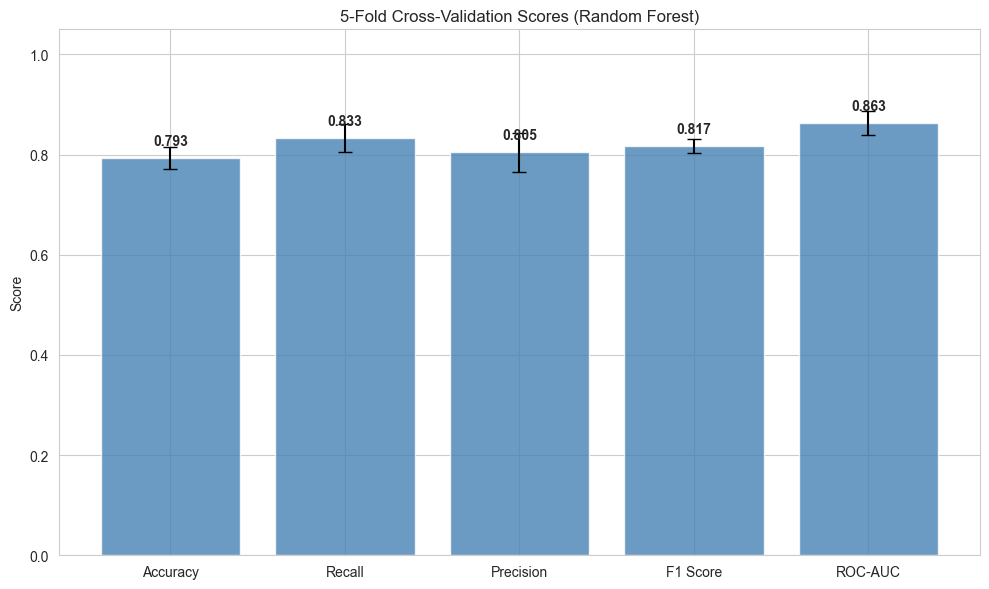

In [14]:
# Visualize cross-validation scores
metrics = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Recall', 'Precision', 'F1 Score', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(10, 6))
val_means = [cv_scores[f'test_{m}'].mean() for m in metrics]
val_stds = [cv_scores[f'test_{m}'].std() for m in metrics]

bars = ax.bar(metric_labels, val_means, yerr=val_stds, capsize=5, color='steelblue', alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation Scores (Random Forest)')

for bar, mean in zip(bars, val_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Test Set Evaluation

In [15]:
# Fit on full training set
rf_pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report (Test Set)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report (Test Set)
              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



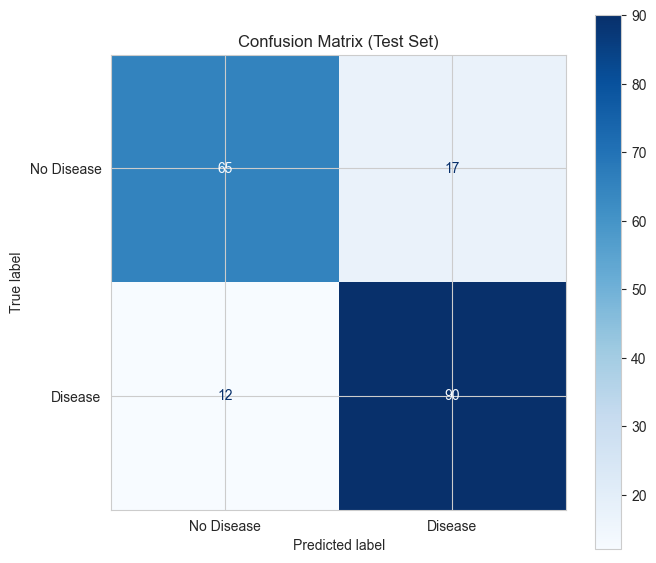

In [16]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

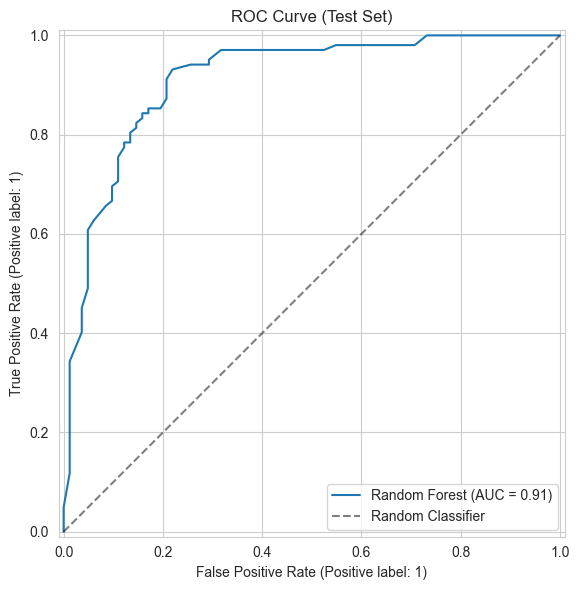

ROC-AUC Score: 0.912


In [17]:
# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_title('ROC Curve (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

### Feature Importance

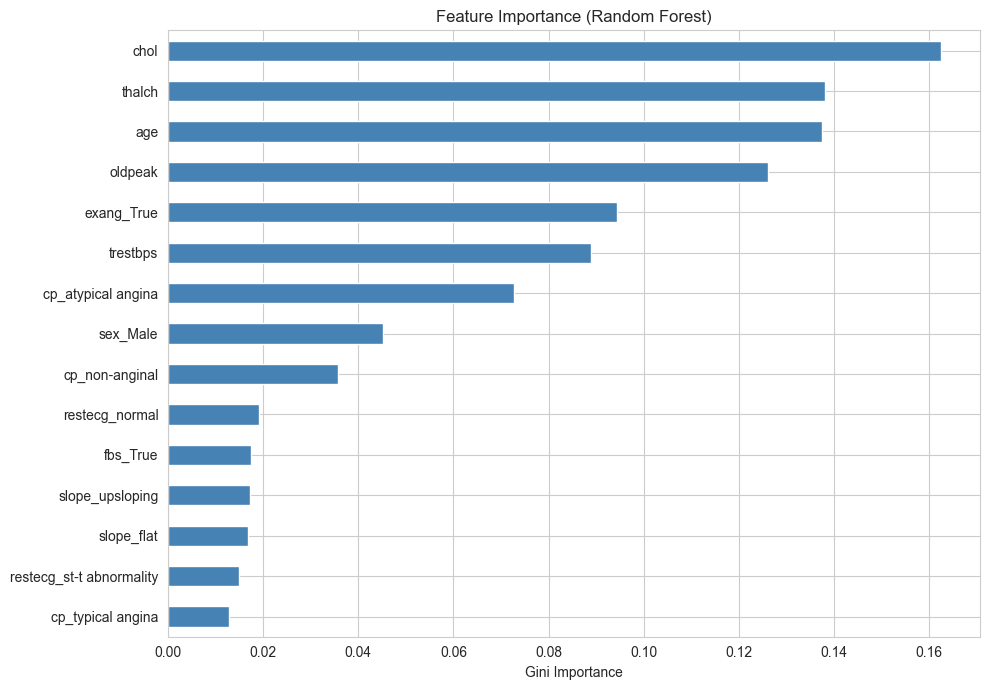

In [18]:
# Extract feature names after preprocessing
feature_names = (
    numerical_cols +
    list(rf_pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_cols))
)

# Get feature importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Sort and plot
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()

In [19]:
# Final summary of test set metrics
test_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall (Sensitivity)', 'Precision', 'F1 Score', 'ROC-AUC'],
    'Score': [
        f"{accuracy_score(y_test, y_pred):.3f}",
        f"{recall_score(y_test, y_pred):.3f}",
        f"{precision_score(y_test, y_pred):.3f}",
        f"{f1_score(y_test, y_pred):.3f}",
        f"{roc_auc_score(y_test, y_prob):.3f}",
    ]
})
test_summary

,Metric,Score
0,Accuracy,0.842
1,Recall (Sensitivity),0.882
2,Precision,0.841
3,F1 Score,0.861
4,ROC-AUC,0.912


## Handoff Notes for Memo Write-Up

### Key EDA Findings
- Dataset: 920 patients, 16 columns. After cleaning: 11 features used for modeling.
- `ca` (66% missing) and `thal` (53% missing) were dropped. `slope` (34% missing) was kept and imputed.
- Target is reasonably balanced: 45% no disease, 55% disease.
- Strongest predictors visible in EDA:
  - `thalch` (max heart rate): disease patients have noticeably lower values
  - `oldpeak` (ST depression): higher values associated with disease
  - `cp` (chest pain type): "asymptomatic" has the highest disease rate
  - `exang` (exercise-induced angina): strong association with disease
- `chol` and `trestbps` show weak separation between classes on their own

### Model Performance (Random Forest, 100 trees)
- **Test set results:**
  - Accuracy: 0.842
  - Recall: 0.882 (correctly identified 88% of disease cases)
  - Precision: 0.841
  - F1 Score: 0.861
  - ROC-AUC: 0.912
- Cross-validation results (5-fold, on training set) were consistent with test set, confirming the model generalizes
- Train scores were 1.000 across all metrics, meaning the model memorizes training data (typical for default Random Forest). Validation/test scores are still strong.

### Best Practices Applied
- 80/20 stratified train/test split
- 5-fold stratified cross-validation
- Preprocessing inside the sklearn Pipeline (prevents data leakage)
- Median imputation for numerical features
- Dropped columns with >50% missing data rather than imputing noise

### Limitations
- Small dataset (920 rows)
- Dropped features (`ca`, `thal`) may contain useful signal
- No hyperparameter tuning performed
- Model should be validated on external data before clinical use

### Potential Next Steps
- Deploy model to AWS